In [1]:
#1- import lib

from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph

#2- Define State

class State(TypedDict):
    text : str
    tokens : list
    token_lengths : list
    total_tokens : int

#3- Define Nodes

def tokenisation_node(state : State):
    text = state["text"]
    S_tokens = text.split()
    return {"tokens" : S_tokens }

def token_lenghts_node(state : State):
    tokens = state["tokens"]
    token_length = [len(token) for token in tokens]
    
    return {"token_lengths" : token_length}

def total_tokens_node(state : State):
    tokens = state["tokens"]
    
    return {"total_tokens" : len(tokens)}

builder = StateGraph(State)

builder.add_node("tokenisation",tokenisation_node)
builder.add_node("token_lenghts",token_lenghts_node)
builder.add_node("total_tokens",total_tokens_node)

#4- connect nodes

builder.add_edge(START ,"tokenisation")
builder.add_edge("tokenisation" , "token_lenghts")
builder.add_edge("tokenisation" , "total_tokens")
builder.add_edge("token_lenghts" , END)
builder.add_edge("total_tokens" , END)

#5- compile graph
graph = builder.compile()

result = graph.invoke(
    {"text": "Welcome To Egypt"}
)

print(result)


{'text': 'Welcome To Egypt', 'tokens': ['Welcome', 'To', 'Egypt'], 'token_lengths': [7, 2, 5], 'total_tokens': 3}


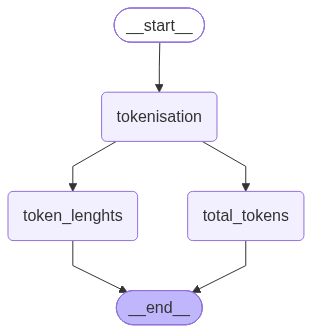

In [2]:
# Display Graph
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))